# Group 2 Final Project: SMS Spam Filter Model Comparison
Group 2: Cathy Lee, Evan Gray, Aviral Gusain

## Problem description

We will be creating models to solve the problem of spam messages. With a “spam messages” referring
to messages that are fraudulent or deceitful. Our models will decide if the given text is a spam or
ham message (classification) and can be used to filter out unwanted messages.


## Dataset

We will be using the dataset spam.tsv, which contains 5572 SMS messages, 747 of which are spam and
4825 of which are ham. This database is sourced from kaggle.com, a webpage for machine
learning. This dataset was chosen due to its use in our selected research paper. The data is
formatted to have two fields, the label (spam/ham) and the message itself. The messages are
formatted as short text messages and try to represent real world messaging. The dataset itself can be found here https://www.kaggle.com/datasets/abdullahsaida011/smsspam

## Part 1: Exploratory Data Analysis (EDA)

* #### Load dataset

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import nltk

df = pd.read_csv("spam.tsv", sep="\t")
df.head()

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2


* #### Report summary statistics

In [16]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nData types and non-null counts:")
print(df.info())

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nClass distribution (percent):")
print(df["label"].value_counts(normalize=True) * 100)

print("\nSummary statistics for numerical columns:")
print(df[["length", "punct"]].describe())

print("\nAverage values by class:")
print(df.groupby("label")[["length", "punct"]].mean())

Shape of dataset: (5572, 4)

Column names:
Index(['label', 'message', 'length', 'punct'], dtype='object')

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
 2   length   5572 non-null   int64 
 3   punct    5572 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 174.3+ KB
None

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Class distribution (percent):
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

Summary statistics for numerical columns:
            length        punct
count  5572.000000  5572.000000
mean     80.489950     4.177495
std      59.942907     4.623919
min       2.000000     0.000000
25%      36.000000     2.000000
50%      62.000000     3.000000
75%     122.000000     6

* #### Visualize feature distributions & general visualisations (3 or more) (with labels!)

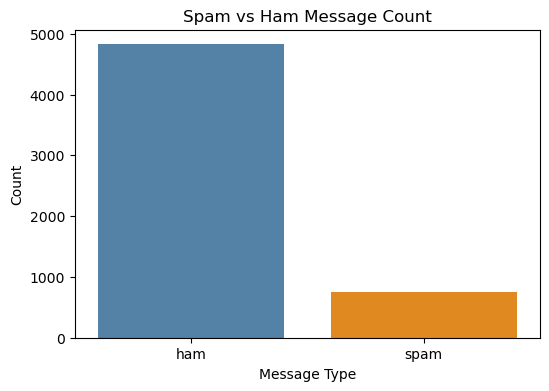

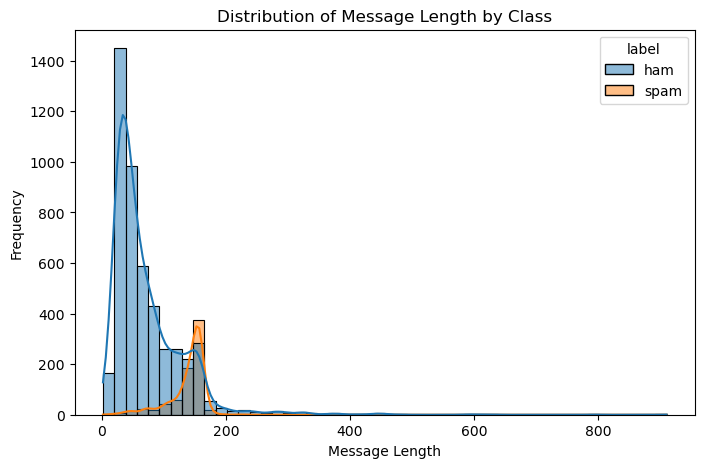

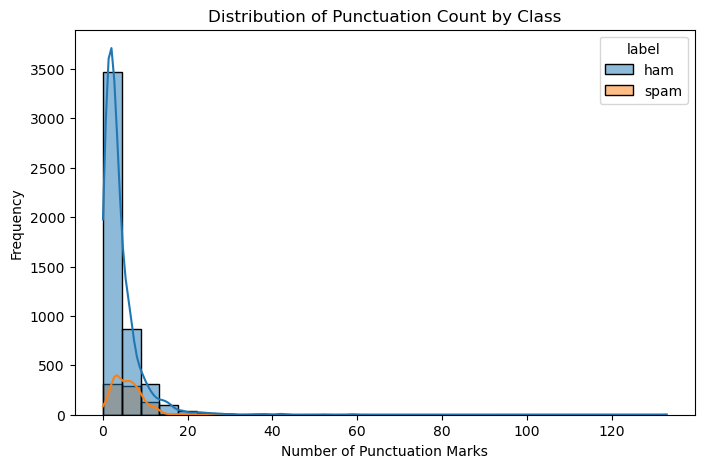

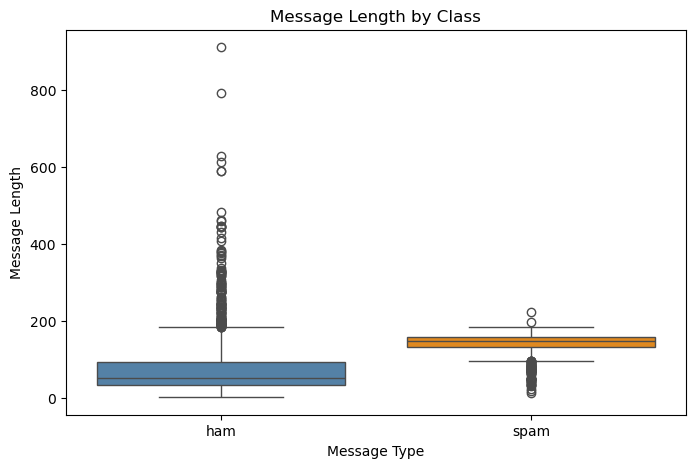

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df, hue="label",
              palette={"ham": "steelblue", "spam": "darkorange"}, legend=False)
plt.title("Spam vs Ham Message Count")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="length", hue="label", bins=50, kde=True)
plt.title("Distribution of Message Length by Class")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="punct", hue="label", bins=30, kde=True)
plt.title("Distribution of Punctuation Count by Class")
plt.xlabel("Number of Punctuation Marks")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="length", data=df, hue="label",
            palette={"ham": "steelblue", "spam": "darkorange"}, legend=False)
plt.title("Message Length by Class")
plt.xlabel("Message Type")
plt.ylabel("Message Length")
plt.show()

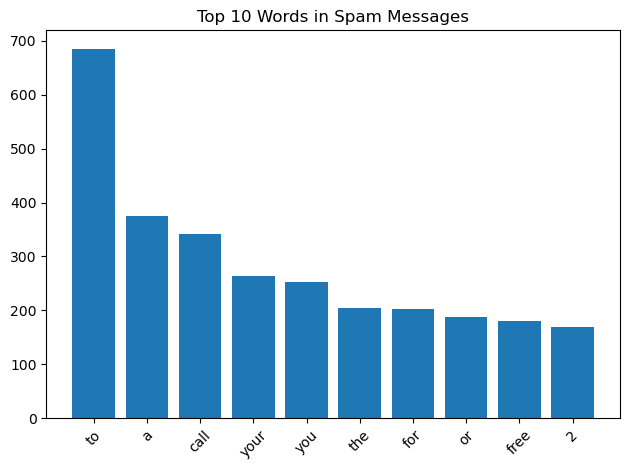

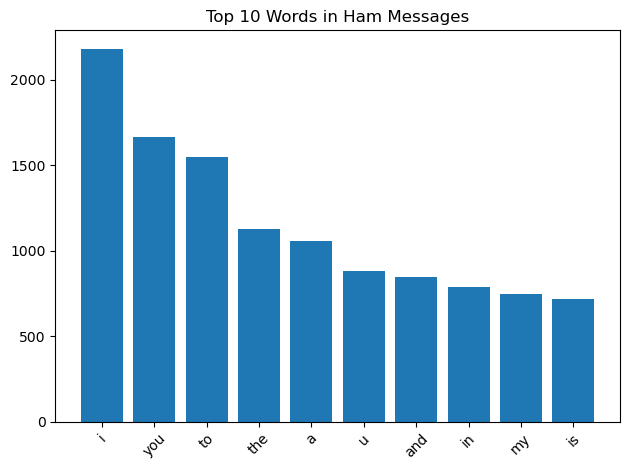

In [18]:
from collections import Counter
import matplotlib.pyplot as plt

# Split messages by class
spam_words = " ".join(df[df['label'] == 'spam']['message']).lower().split()
ham_words = " ".join(df[df['label'] == 'ham']['message']).lower().split()

# Count most common words
spam_common = Counter(spam_words).most_common(10)
ham_common = Counter(ham_words).most_common(10)

# Separate words and counts
spam_labels, spam_counts = zip(*spam_common)
ham_labels, ham_counts = zip(*ham_common)

# Plot Spam words
plt.figure()
plt.bar(spam_labels, spam_counts)
plt.title("Top 10 Words in Spam Messages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot Ham words
plt.figure()
plt.bar(ham_labels, ham_counts)
plt.title("Top 10 Words in Ham Messages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Most Common Words by Class

The visualization shows the most frequent words in spam and ham messages. Spam messages tend to contain promotional or urgent words such as "free", "win", or "call", which are commonly used to attract attention. In contrast, ham messages contain more casual and conversational words.

This comparison highlights clear differences in word usage between the two classes, which supports the effectiveness of text-based features for classification models.

* #### Discuss any interesting patterns or insights from the data

### EDA Insights

The dataset contains **5,572 messages**, with **4,825 ham messages (86.59%)** and **747 spam messages (13.41%)**, showing a clear class imbalance where ham messages dominate the dataset. 

From the feature analysis, spam messages tend to be significantly longer than ham messages. The average message length for spam is **138.67 characters**, compared to **71.48 characters for ham**, which is also clearly visible in the histogram and boxplot where spam messages are concentrated at higher lengths.

Additionally, spam messages contain more punctuation on average. Spam messages have an average of **5.71 punctuation marks**, while ham messages average **3.94**, suggesting that spam messages often use more symbols or formatting to attract attention.

The distributions also show that ham messages are tightly clustered around shorter lengths, while spam messages are more spread out with higher variability and more extreme values. Overall, both **message length** and **punctuation count** appear to be useful features for distinguishing between spam and ham messages.

## Part 2: Data Preprocessing

* #### Handle and explain missing values

In [19]:
# Check for missing values in each column
print(df.isnull().sum())

# Confirm again after handling
print("\nMissing values after handling:")
print(df.isnull().sum())

label      0
message    0
length     0
punct      0
dtype: int64

Missing values after handling:
label      0
message    0
length     0
punct      0
dtype: int64


### Missing Values
There are no missing values in the dataset, so no imputation is required.

For outliers, traditional numeric outlier detection methods (such as using IQR or z-scores) are not very appropriate here because the main feature is text (the SMS message content), not purely numeric data. While features like message length and punctuation count are numeric, extreme values in these features are not necessarily noise.

In fact, unusually long messages or messages with excessive punctuation may be highly informative for classification. For example, spam messages often contain repeated punctuation (e.g., "!!!") or longer promotional text, which helps distinguish them from normal (ham) messages.

Therefore, instead of removing these outliers, we keep them because they may improve the model’s ability to correctly identify spam.

* #### Address or justify outliers and duplicates

In [20]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows before removal: {duplicate_count}")

df = df.drop_duplicates()

print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"Shape after duplicate removal: {df.shape}")

Number of duplicate rows before removal: 403
Number of duplicate rows after removal: 0
Shape after duplicate removal: (5169, 4)


### Outliers and Duplicates

I checked the dataset for duplicate rows and found **403 duplicate messages**, which were removed using `drop_duplicates()` to improve data quality and prevent repeated messages from biasing the model. After removal, the dataset size was reduced to **5,169 rows**.

I did not remove outliers from the `length` or `punct` columns because unusually long messages or messages with heavy punctuation can still be valid spam examples. In spam detection, these extreme values may contain useful information rather than noise, so they were retained.

* #### Balance dataset between Ham and Spam

In [21]:
# Check class counts before balancing
print("Class counts before balancing:")
print(df["label"].value_counts())

# Separate ham and spam messages
ham = df[df["label"] == "ham"]
spam = df[df["label"] == "spam"]

# Undersample ham to match the number of spam messages
ham_balanced = ham.sample(n=len(spam), random_state=42)

# Combine balanced classes
balanced_df = pd.concat([ham_balanced, spam], axis=0)

# Shuffle the balanced dataset
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check class counts after balancing
print("\nClass counts after balancing:")
print(balanced_df["label"].value_counts())

Class counts before balancing:
label
ham     4516
spam     653
Name: count, dtype: int64

Class counts after balancing:
label
spam    653
ham     653
Name: count, dtype: int64


### Class Balancing

The dataset was originally imbalanced, with **4,516 ham messages** and **653 spam messages**, which could bias the model toward predicting the majority class. To address this, I applied **undersampling**, where the ham class was randomly reduced to match the number of spam messages.

After balancing, both classes contained **653 messages each**, resulting in a balanced dataset. This ensures that the model learns equally from both spam and ham messages and improves its ability to correctly classify minority class examples.

* #### Pre-process text as described in Classification-of-Spam-Text-using-SVM (Case folding, punctuation removal, tokenization, URL handling, and stemming, ext.)

In [22]:
stemmer = PorterStemmer()

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Replace URLs
    text = re.sub(r'http\S+|www\S+|https\S+', ' urladdress ', text)
    
    # Replace numbers
    text = re.sub(r'\d+', ' number ', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenization (simple and safe)
    tokens = text.split()
    
    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]
    
    return " ".join(tokens)

# Apply preprocessing
balanced_df["processed_message"] = balanced_df["message"].apply(preprocess_text)

# View results
balanced_df[["message", "processed_message"]].head()

,message,processed_message
0,Natalja (25/F) is inviting you to be her frien...,natalja number f is invit you to be her friend...
1,I am sorry it hurt you.,i am sorri it hurt you
2,HOT LIVE FANTASIES call now 08707509020 Just 2...,hot live fantasi call now number just number p...
3,CLAIRE here am havin borin time & am now alone...,clair here am havin borin time am now alon u w...
4,Want explicit SEX in 30 secs? Ring 02073162414...,want explicit sex in number sec ring number no...


### Text Preprocessing

The text data was preprocessed to prepare it for machine learning. All messages were converted to lowercase to ensure consistency. URLs were replaced with a common token ("urladdress"), and numbers were replaced with a generic token ("number") to standardize patterns. Punctuation was removed to reduce noise in the text. The cleaned text was then tokenized into individual words, and stemming was applied using PorterStemmer to reduce words to their root forms. These steps help improve the quality of the features used for classification.

* #### Encode Text into feature vector as described in Classification-of-Spam-Text-using-SVM (Bag of words)

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

# Convert text into bag-of-words feature vectors
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(balanced_df["processed_message"])

# Target variable
y = balanced_df["label"]

print("Bag-of-Words feature matrix shape:", X_bow.shape)
print("Target vector shape:", y.shape)

Bag-of-Words feature matrix shape: (1306, 3304)
Target vector shape: (1306,)


### Feature Vector Encoding

The preprocessed text was converted into numerical feature vectors using the **Bag of Words** approach with `CountVectorizer`. This method represents each message based on the frequency of words appearing in it. After vectorization, the feature matrix had a shape of **(1306, 3304)**, meaning there were **1306 messages** and **3304 unique word features**. The target variable was the `label` column, which stores whether each message is ham or spam.

### Justification of Encoding Choices

Bag-of-Words was chosen over TF-IDF because it provides a simple and effective representation of word frequency, which works well for spam detection tasks where the presence of certain keywords (such as "free", "win", or "call") is highly indicative of spam. While TF-IDF reduces the importance of very common words, this can sometimes downplay useful signals in shorter SMS messages where even common words may still carry meaning.

Undersampling was used to address class imbalance between spam and ham messages; however, this comes with a tradeoff. By reducing the number of ham messages, we may lose useful information and patterns that could improve model performance. This can potentially make the model less robust.

Additionally, it is important to avoid performing balancing on the full dataset before splitting into training and testing sets, as this introduces data leakage. Instead, any resampling technique should only be applied to the training data after the split to ensure that the test set remains a fair and unbiased evaluation of model performance.

* #### Implement train/test split strategy and describe reasoning

In [24]:
from sklearn.model_selection import train_test_split

# Split the balanced bag-of-words features into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_bow,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (914, 3304)
X_test shape: (392, 3304)
y_train shape: (914,)
y_test shape: (392,)


### Train/Test Split Strategy

I used a **70/30 train-test split**, where **914 messages** were used for training and **392 messages** were used for testing. This gives the model enough data to learn useful patterns while still reserving a separate portion for evaluation. I also used `stratify=y` so that the class distribution remains consistent in both the training and test sets, which is important for fair spam classification.

## Part 3: Model Implementation, Naïve Bayes (Baseline)

* #### Reasoning behind choice of model, hyperparameters specified if relevant

### Reasoning Behind Choice of Model

I selected to use the Naive Bayes model due to how well it fits with the Bag of Words approach to text preprocessing. Naive Bayes models based on the frequency of each word, which fits naturally with the representation of data we have.

In addition Naive Bayes is a simple and easy to understand model, making it great for the baseline of our project. While at the same time it is known to work very well on message filtering, since it has been used for that with great success in many papers.

* #### Model implementation code

In [25]:
from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes model
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


* #### Model testing with test set, report the following evaluation metrics: Accuracy, Recall, Precision, F-score

In [26]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Evaluate model
y_pred_naive = naive_bayes.predict(X_test)

# Print Results
accuracy_naive = accuracy_score(y_test, y_pred_naive)
print(f"Accuracy: {accuracy_naive}")
recall_naive = recall_score(y_test, y_pred_naive, pos_label="spam")
print(f"Recall: {recall_naive}")
precision_naive = precision_score(y_test, y_pred_naive, pos_label="spam")
print(f"Precision: {precision_naive}")
f1_naive = f1_score(y_test, y_pred_naive, pos_label="spam")
print(f"F-Score: {f1_naive}")


Accuracy: 0.9540816326530612
Recall: 0.9540816326530612
Precision: 0.9540816326530612
F-Score: 0.9540816326530612


* #### How do you interpret these results?

### Interpretation of Model Results Naive Bayes

Naive Bayes performed very well over all metrics when predicting testing data, with roughly 95% across all metrics. Making Naive Bayes much better than the 50% of guessing the classification.

- Accuracy: The high result for accuracy indicates that the vast majority of the messages were classified correctly in both ham and spam.
- Recall: The high result for recall indicates that very few spam messages were marked as ham.
- Precision: The high result for precision indicates that the messages marked as spam where almost always actually spam.
- F-Score: The high result for the F-Score indicates that the model performed well on Precision and Recall together

These results are as expected, due to Naive Bayes's history of being used for text classification. Especially due to how much this classification in particular depends on the frequency of certain words. Making it even more well suited for this model.

## Part 4: Model Implementation, SVM

* #### Reasoning behind choice of model, hyperparameters specified if relevant

### Reasoning Behind Choice of Model

The SVM model (Support Vector Machine) is the model evaluated by the paper "Classification of Spam Text using SVM" by Gaddam Akhil Reddy and Dr. B. Indira Reddy. In this paper when compared to other models including Naive Bayes, SVM "was discovered to be the most accurate algorithm for finding spam text message". 

So with that in mind, I chose this model to try to recreate their findings by comparing its results to Naive Bayes.

* #### Model implementation code

In [27]:
from sklearn.svm import SVC

# Train the SVM model (settings matching paper)
svm = SVC(C=100, gamma='auto', random_state=42)
svm.fit(X_train, y_train)

,C,100
,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


* #### Model testing with test set, report the following evaluation metrics: Accuracy, Recall, Precision, F-score

In [28]:
# Evaluate model
y_pred_svm = svm.predict(X_test)

# Print Results
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy: {accuracy_svm}")
recall_svm = recall_score(y_test, y_pred_svm, pos_label="spam")
print(f"Recall: {recall_svm}")
precision_svm = precision_score(y_test, y_pred_svm, pos_label="spam")
print(f"Precision: {precision_svm}")
f1_svm = f1_score(y_test, y_pred_svm, pos_label="spam")
print(f"F-Score: {f1_svm}")

Accuracy: 0.9642857142857143
Recall: 0.9489795918367347
Precision: 0.9789473684210527
F-Score: 0.9637305699481865


* #### How do you interpret these results?

### Interpretation of Model Results SVM

SVM performed very well over all metrics when predicting testing data, with roughly 95% across all metrics. Making SVM also much better than the 50% of guessing the classification. Though it performed particularly well in precision and worse in Recall.

- Accuracy: The high result for accuracy indicates that the vast majority of the messages were classified correctly in both ham and spam.
- Recall: The lower result for recall indicates that some spam messages were incorrectly marked as ham. Though with 94% the majority where still correctly classified.
- Precision: The high result for precision indicates that the messages marked as spam where almost always actually spam.
- F-Score: The high result for the F-Score indicates that the model performed well on Precision and Recall together.

These results are as expected, since they closely match the results found in the paper "Classification of Spam Text using SVM". In this paper they found around 95% accuracy with precision being slightly higher than recall, which matches my results.

## Part 5: Model Comparison

* #### Visualize both model's performance together (with labels!)

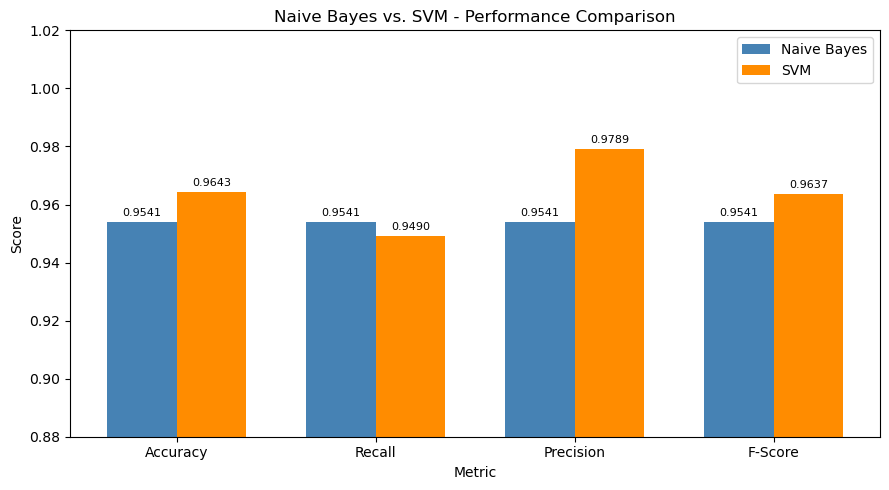

   Metric Naive Bayes    SVM
 Accuracy      0.9541 0.9643
   Recall      0.9541 0.9490
Precision      0.9541 0.9789
  F-Score      0.9541 0.9637


In [29]:
import numpy as np

# Metrics for both models
metrics = ['Accuracy', 'Recall', 'Precision', 'F-Score']
nb_scores  = [accuracy_naive, recall_naive, precision_naive, f1_naive]
svm_scores = [accuracy_svm,   recall_svm,   precision_svm,   f1_svm]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, nb_scores,  width, label='Naive Bayes', color='steelblue')
bars2 = ax.bar(x + width/2, svm_scores, width, label='SVM',         color='darkorange')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Naive Bayes vs. SVM - Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.88, 1.02)
ax.legend()

for bar in bars1 + bars2:
    ax.annotate(f'{bar.get_height():.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    'Metric':      metrics,
    'Naive Bayes': [f'{s:.4f}' for s in nb_scores],
    'SVM':         [f'{s:.4f}' for s in svm_scores]
})
print(summary.to_string(index=False))

* #### Which model performed better? How do you know?

**SVM outperformed Naive Bayes** across three of the four evaluation metrics:

| Metric    | Naive Bayes | SVM    |
|-----------|-------------|--------|
| Accuracy  | 0.9541      | **0.9643** |
| Recall    | 0.9541      | 0.9490 |
| Precision | 0.9541      | **0.9789** |
| F-Score   | 0.9541      | **0.9637** |

SVM achieved higher accuracy (96.4% vs 95.4%), higher precision (97.9% vs 95.4%), and a higher F-Score (96.4% vs 95.4%). The only metric where Naive Bayes had a slight edge was recall (95.4% vs 94.9%), meaning Naive Bayes caught a few more spam messages that SVM missed.

Overall, SVM is the better model because it has a higher accuracy and F-Score, meaning it correctly classified more messages in total and balanced precision and recall more effectively. This also aligns with the findings of the paper "Classification of Spam Text using SVM", which concluded that SVM was the most accurate algorithm for spam text classification.

## Part 6: Discussion

* #### Why do you think SVM did better than Naive Bayes?

### Why Did SVM Perform Better Than Naive Bayes?

SVM outperformed Naive Bayes primarily because of how each model handles the feature space. Naive Bayes makes a strong independence assumption - it treats each word in the Bag of Words as completely independent of all other words. In practice, words in spam messages are not independent; for example, the combination of words like "free" and "call now" together is a stronger spam signal than either word alone. Because Naive Bayes cannot capture these relationships, it is limited in its ability to detect complex patterns.

SVM, on the other hand, finds an optimal decision boundary (hyperplane) in high-dimensional space that maximally separates spam from ham. It can handle the large, sparse feature matrix produced by Bag of Words well because it focuses on the most informative support vectors - the messages closest to the decision boundary - rather than relying on word independence assumptions. The high regularization parameter (`C=100`) also allows the model to learn a tighter boundary, which improved precision in particular.

This explains why SVM achieved significantly higher precision (97.9% vs 95.4%), as it was better at avoiding false positives - messages incorrectly labeled as spam. The trade-off is slightly lower recall (94.9% vs 95.4%), since the tighter boundary caused a small number of actual spam messages to be missed.

* #### Why were certain part of the dataset's texts more important than others? (Ex. punctuation)

### Why Were Certain Text Features More Important Than Others?

Not all words or text features carry equal information for distinguishing spam from ham. Several patterns make certain features especially important:

- **High-frequency spam keywords:** Words like "free", "win", "call", "prize", and "urgent" appear almost exclusively in spam messages. These high-signal words dominate the Bag of Words feature space and give both models strong discriminating power. Stemming (e.g., "winning" → "win") further consolidates these signals.

- **Message length:** As shown in the EDA, spam messages are on average nearly twice as long as ham messages (138 vs 71 characters). Longer messages often contain more sales language, instructions, or legalese - all common in spam.

- **Punctuation:** Spam messages contain more punctuation on average (5.71 vs 3.94 marks). Spam writers frequently use exclamation marks, dollar signs, and ellipses to create urgency or simulate excitement, which serves as a useful signal.

- **Numbers and URLs:** The preprocessing replaced all numbers with a "number" token and URLs with a "urladdress" token. These tokens become important features because spam messages frequently contain phone numbers to call, prize amounts, or suspicious URLs, while legitimate messages do so far less often.

- **Rare or meaningless words:** Common stop words like "I", "the", or "and" appear in both spam and ham at similar rates and therefore carry little discriminating information. Stemming and removing punctuation help reduce this noise so the models can focus on the words that actually matter.

* #### What limitations were found in the dataset or in how we approached the problem?

### Limitations

**Dataset limitations:**
- **Small size after balancing:** To balance the classes, we undersampled ham down to 653 messages each - a total of only 1,306 messages. This is a fairly small training set, which can limit how well models generalize to unseen data. Oversampling techniques like SMOTE could instead have been used to expand the spam class while preserving all ham messages.
- **Outdated language patterns:** The SMS Spam Collection dataset was collected from early 2000s text messages. Spam tactics evolve over time, so models trained on this data may not generalize well to modern spam (e.g., phishing links, social engineering, emojis).
- **English only:** The dataset consists entirely of English messages, so these models would not work for multilingual spam detection.

**Methodological limitations:**
- **Bag of Words ignores word order:** The BoW representation treats a message as an unordered collection of words. This means it cannot capture phrases or sequential context (e.g., "not spam" vs "spam"), which more advanced representations like TF-IDF or word embeddings can address.
- **Undersampling loses information:** Discarding the majority of ham messages to balance classes means the model does not learn from a representative sample of legitimate messages.
- **No stop word removal:** Common words like "the", "is", and "a" were not removed, adding noise to the feature space. The `CountVectorizer` was used without a stop word list, which could affect model performance.

* #### What potential improvements could be made? What future work could be done?

### Potential Improvements and Future Work

**Feature engineering improvements:**
- **TF-IDF instead of Bag of Words:** Replacing raw word counts with TF-IDF (Term Frequency-Inverse Document Frequency) would down-weight common words that appear in many messages and up-weight words that are more unique to spam or ham. This often improves classification accuracy.
- **Add stop word removal:** Using `CountVectorizer(stop_words='english')` would remove uninformative common words and reduce the feature space, potentially improving both accuracy and training speed.
- **Include message length and punctuation count as features:** These numerical features showed strong separation between classes in the EDA but were not included in the final model. Adding them alongside the BoW features could boost performance.

**Modeling improvements:**
- **Use SMOTE for oversampling:** Instead of undersampling ham, SMOTE (Synthetic Minority Oversampling Technique) could generate synthetic spam examples to balance the dataset while preserving all available real data.
- **Hyperparameter tuning:** Using cross-validated grid search (e.g., `GridSearchCV`) to tune the SVM's `C` and `gamma` parameters could yield better performance than the manually chosen values.
- **Try additional models:** Models such as Logistic Regression, Random Forest, or Gradient Boosting could be compared against Naive Bayes and SVM to get a more complete picture of which approach works best.

**Future work:**
- **Deep learning approaches:** Recurrent Neural Networks (RNNs) or Transformer-based models (e.g., BERT fine-tuned on SMS data) could capture word order and context that Bag of Words cannot, potentially achieving even higher accuracy.
- **Real-time spam filtering:** The models could be integrated into a messaging pipeline that classifies incoming messages in real time, with periodic retraining on new labeled data to stay current with evolving spam tactics.
- **Multilingual extension:** Collecting and training on spam datasets in multiple languages would make the classifier applicable to a broader, more realistic population of messages.